# Assessment #2 – Agent-Based Driving Scenes Training using nuScenes

## Dataset Used

For this assessment, the following nuScenes datasets were downloaded and used:

- **nuScenes v1.0-mini [US]** (Full dataset mini subset)
- **CAN Bus Expansion [US]**
- **Map Expansion [US]**

### Dataset Root Directory: 
D:/Assessement2/data/sets/nuscenes

In [1]:
%matplotlib inline
from nuscenes.nuscenes import NuScenes
from nuscenes.map_expansion.map_api import NuScenesMap

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from collections import defaultdict

import torch
import metadrive
import scenarionet
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from metadrive.envs.scenario_env import ScenarioEnv

import imageio

In [2]:
DATAROOT = "D:/Assessement2/data/sets/nuscenes"
nusc = NuScenes(version='v1.0-mini', dataroot=DATAROOT, verbose=True)

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.477 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


In [3]:
for scene in nusc.scene:
    name = scene['name']
    desc = scene['description']
    
    # Get location from the linked log
    log_token = scene['log_token']
    log_record = nusc.get('log', log_token)  # This fetches the log entry
    location = log_record['location']        # Now safe to access
    
    nbr_samples = scene['nbr_samples']
    duration_sec = nbr_samples / 2  # approx, since 2 Hz keyframes
    
    print(f"Scene: {name}")
    print(f"Description: {desc}")
    print(f"Location: {location}")
    print(f"Duration: ~{duration_sec:.1f} seconds")
    print(f"Number of samples: {nbr_samples}")
    print("-" * 70)

Scene: scene-0061
Description: Parked truck, construction, intersection, turn left, following a van
Location: singapore-onenorth
Duration: ~19.5 seconds
Number of samples: 39
----------------------------------------------------------------------
Scene: scene-0103
Description: Many peds right, wait for turning car, long bike rack left, cyclist
Location: boston-seaport
Duration: ~20.0 seconds
Number of samples: 40
----------------------------------------------------------------------
Scene: scene-0553
Description: Wait at intersection, bicycle, large truck, peds crossing crosswalk, ped with stroller
Location: boston-seaport
Duration: ~20.5 seconds
Number of samples: 41
----------------------------------------------------------------------
Scene: scene-0655
Description: Parking lot, parked cars, jaywalker, bendy bus, gardening vehicles
Location: boston-seaport
Duration: ~20.5 seconds
Number of samples: 41
----------------------------------------------------------------------
Scene: scene-

## Question 1: Scenario Extraction from nuScenes

### Objective
The objective of this task is to automatically extract and classify different real-world driving scenarios from the nuScenes dataset that are relevant for training a reinforcement learning (RL) autonomous vehicle agent. The extracted scenarios include:

- Highway driving
- Intersection driving
- Roundabout driving
- Collision / near-miss scenarios

---

### Dataset and Map Usage
This implementation uses:
- Ego vehicle pose data
- Semantic map data from **nuScenes Map Expansion**
- Object annotations for vehicles and pedestrians

Maps from the following locations are loaded once to improve efficiency:
- Boston Seaport
- Singapore Holland Village
- Singapore One North
- Singapore Queenstown

---

### Scenario Detection Methodology

#### 1. Ego Trajectory Extraction
For each scene, the ego vehicle’s 2D trajectory is extracted by iterating through all samples and collecting ego pose translations. This trajectory serves as the basis for motion pattern analysis.

#### 2. Highway Driving Detection
Highway scenes are detected using a geometric straightness metric defined as:

**Straightness Ratio = Displacement / Path Length**

If the ratio exceeds a threshold (0.95), the trajectory is considered straight and classified as highway driving.

#### 3. Roundabout Detection
Roundabout scenarios are identified by computing cumulative heading changes along the trajectory. If the total angular change exceeds 300 degrees and sufficient displacement is observed, the motion is classified as circular (roundabout driving).

#### 4. Intersection Detection
Intersection driving is detected using semantic map queries. For each ego position, a spatial patch is queried to check if the ego vehicle is located within a road segment marked as an intersection in the nuScenes map.

#### 5. Near-Miss / Collision Detection
Near-miss scenarios are detected by measuring the distance between the ego vehicle and nearby annotated vehicles or pedestrians. If the distance falls below a critical threshold (3 meters), the scene is classified as a collision or near-miss scenario.

---

### Scenario Classification Logic
Each scene is evaluated using the following priority:
1. Scenes with negligible movement are ignored
2. Highway motion detection
3. Roundabout motion detection
4. Intersection-based semantic detection
5. Near-miss detection (can overlap with other categories)

---

### Output
The code outputs lists and counts of detected scenes for:
- Highway driving
- Intersection driving
- Roundabout driving
- Near-miss scenarios
- Other scenes

In [4]:
# ============================
# Configuration
# ============================

PATCH_SIZE = 8.0
CRITICAL_DISTANCE = 3.0

locations = [
    'boston-seaport',
    'singapore-hollandvillage',
    'singapore-onenorth',
    'singapore-queenstown'
]

# ============================
# Load Maps Once
# ============================

print("Loading maps...")

nusc_maps = {}

for loc in locations:
    try:
        nusc_maps[loc] = NuScenesMap(dataroot=DATAROOT, map_name=loc)
        print("Loaded:", loc)
    except:
        print("Failed:", loc)

# ============================
# Helper Functions
# ============================

def get_ego_trajectory(scene):
    """Extract ego vehicle trajectory for a scene."""
    
    sample_token = scene['first_sample_token']
    positions = []
    
    while sample_token:
        sample = nusc.get('sample', sample_token)
        sd = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
        ego = nusc.get('ego_pose', sd['ego_pose_token'])
        
        positions.append(ego['translation'][:2])
        sample_token = sample['next']
        
    return np.array(positions)


def is_highway(ego_positions, straightness_threshold=0.95):
    """Detect straight highway-like driving."""
    
    diffs = np.diff(ego_positions, axis=0)
    segment_lengths = np.linalg.norm(diffs, axis=1)
    
    path_length = np.sum(segment_lengths)
    displacement = np.linalg.norm(ego_positions[-1] - ego_positions[0])
    
    if path_length == 0:
        return False
    
    ratio = displacement / path_length
    
    return ratio >= straightness_threshold


def is_roundabout(ego_positions, min_turn_deg=300, min_displacement=5):
    """Detect circular motion (roundabout)."""
    
    displacement = np.linalg.norm(ego_positions[-1] - ego_positions[0])
    
    if displacement < min_displacement:
        return False
    
    vectors = np.diff(ego_positions, axis=0)
    
    angles = (
        np.arctan2(vectors[1:,1], vectors[1:,0]) -
        np.arctan2(vectors[:-1,1], vectors[:-1,0])
    )
    
    angles = (angles + np.pi) % (2*np.pi) - np.pi
    
    total_turn = np.sum(np.abs(np.degrees(angles)))
    
    return total_turn >= min_turn_deg


def is_intersection(scene):
    """Detect intersection using map."""
    
    log = nusc.get('log', scene['log_token'])
    location = log['location']
    
    if location not in nusc_maps:
        return False
    
    nmap = nusc_maps[location]
    
    sample_token = scene['first_sample_token']
    
    while sample_token != '':
        
        sample = nusc.get('sample', sample_token)
        sd = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
        ego = nusc.get('ego_pose', sd['ego_pose_token'])
        
        x, y = ego['translation'][:2]
        patch = (x, y, PATCH_SIZE, PATCH_SIZE)
        
        records = nmap.get_records_in_patch(
            patch,
            ['road_segment'],
            mode='intersect'
        )
        
        for token in records['road_segment']:
            road = nmap.get('road_segment', token)
            
            if road.get('is_intersection', False):
                return True
        
        sample_token = sample['next']
    
    return False


def is_near_miss(scene):
    """Detect near-miss or collision scenario."""
    
    sample_token = scene['first_sample_token']
    
    while sample_token != '':
        
        sample = nusc.get('sample', sample_token)
        
        sd = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
        ego = nusc.get('ego_pose', sd['ego_pose_token'])
        ego_pos = np.array(ego['translation'])
        
        for ann_token in sample['anns']:
            
            ann = nusc.get('sample_annotation', ann_token)
            
            if 'vehicle' in ann['category_name'] or 'human' in ann['category_name']:
                
                obj_pos = np.array(ann['translation'])
                
                dist = np.linalg.norm((ego_pos - obj_pos)[:2])
                
                if dist < CRITICAL_DISTANCE:
                    return True
        
        sample_token = sample['next']
    
    return False


# ============================
# Scenario Classification
# ============================

print("\nScanning scenes...\n")

highway_scenes = []
intersection_scenes = []
roundabout_scenes = []
near_miss_scenes = []
other_scenes = []

for scene in nusc.scene:
    
    ego_positions = get_ego_trajectory(scene)
    
    displacement = np.linalg.norm(ego_positions[-1] - ego_positions[0])
    
    # Ignore tiny movement scenes
    if displacement < 2:
        other_scenes.append(scene['name'])
        continue
    
    if is_highway(ego_positions):
        highway_scenes.append(scene['name'])
    
    elif is_roundabout(ego_positions):
        roundabout_scenes.append(scene['name'])
    
    elif is_intersection(scene):
        intersection_scenes.append(scene['name'])
    
    else:
        other_scenes.append(scene['name'])
    
    if is_near_miss(scene):
        near_miss_scenes.append(scene['name'])


# ============================
# Results
# ============================

print("================================")
print("SCENARIO DETECTION RESULTS")
print("================================")

print("\nHighway scenes:", len(highway_scenes))
print(highway_scenes)

print("\nIntersection scenes:", len(intersection_scenes))
print(intersection_scenes)

print("\nRoundabout scenes:", len(roundabout_scenes))
print(roundabout_scenes)

print("\nNear-miss scenes:", len(near_miss_scenes))
print(near_miss_scenes)

print("\nOther scenes:", len(other_scenes))

Loading maps...
Loaded: boston-seaport
Loaded: singapore-hollandvillage
Loaded: singapore-onenorth
Loaded: singapore-queenstown

Scanning scenes...

SCENARIO DETECTION RESULTS

Highway scenes: 5
['scene-0103', 'scene-0655', 'scene-0757', 'scene-0796', 'scene-1077']

Intersection scenes: 3
['scene-0061', 'scene-0916', 'scene-1094']

Roundabout scenes: 0
[]

Near-miss scenes: 1
['scene-0061']

Other scenes: 2


## Visualization of Extracted Scenarios (Supporting Question 1)

To validate the correctness of scenario classification, semantic map layers from nuScenes Map Expansion are visualized together with ego vehicle trajectories.

The following semantic layers are rendered:

- drivable_area
- walkway
- stop_line

For each scene:

1. The ego trajectory is extracted.
2. A spatial radius is defined around the mean trajeation before RL training.

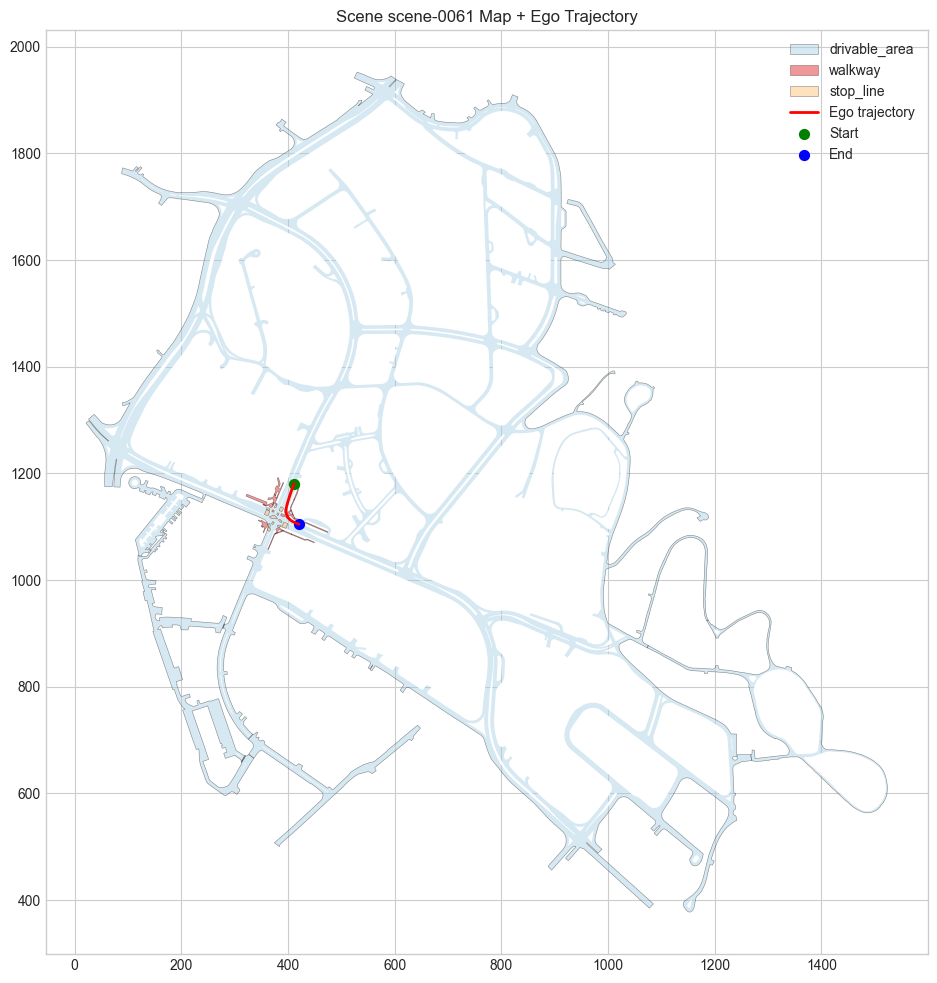

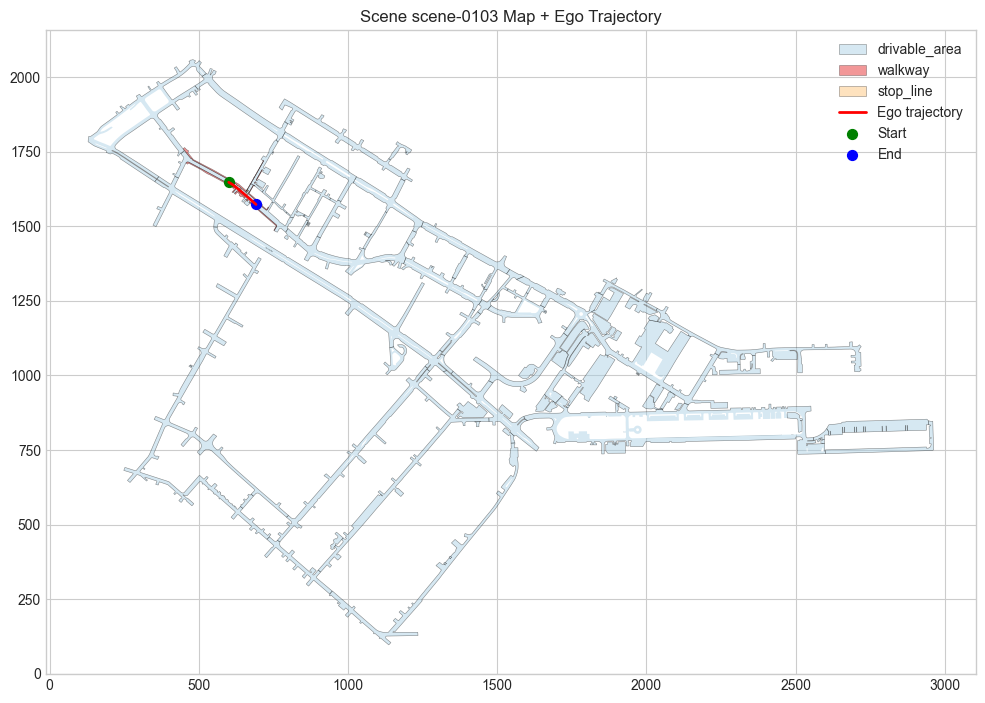

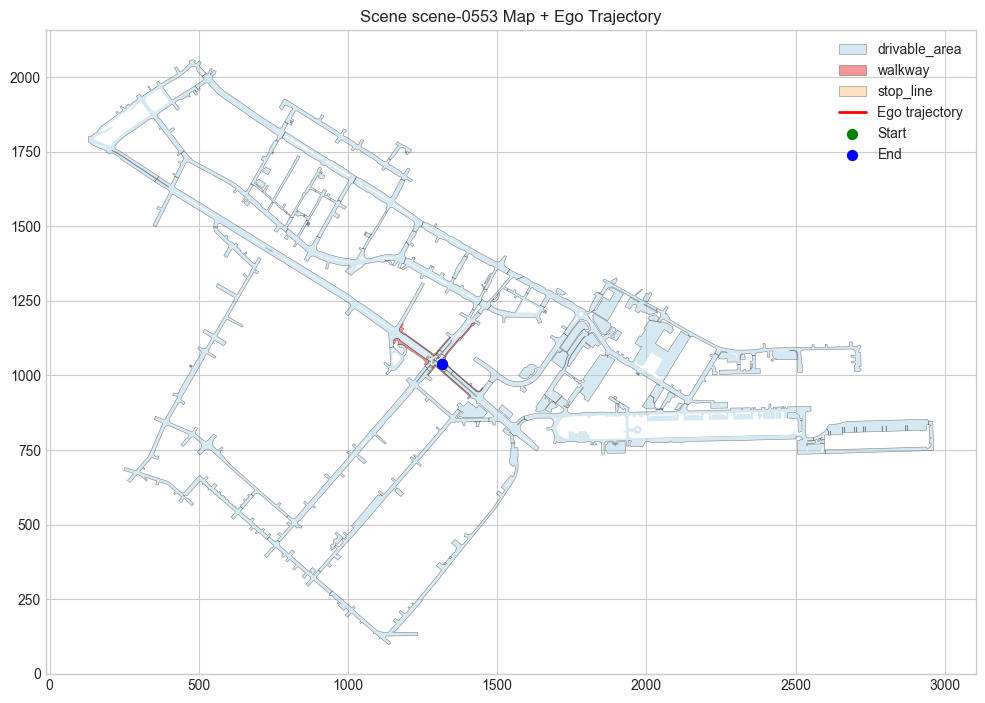

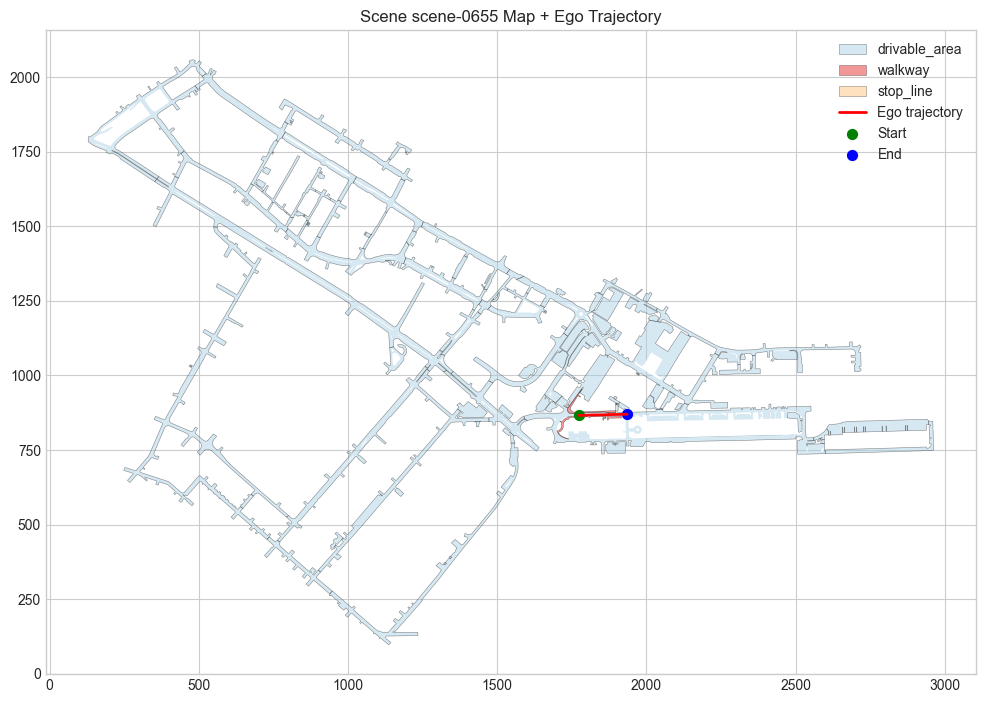

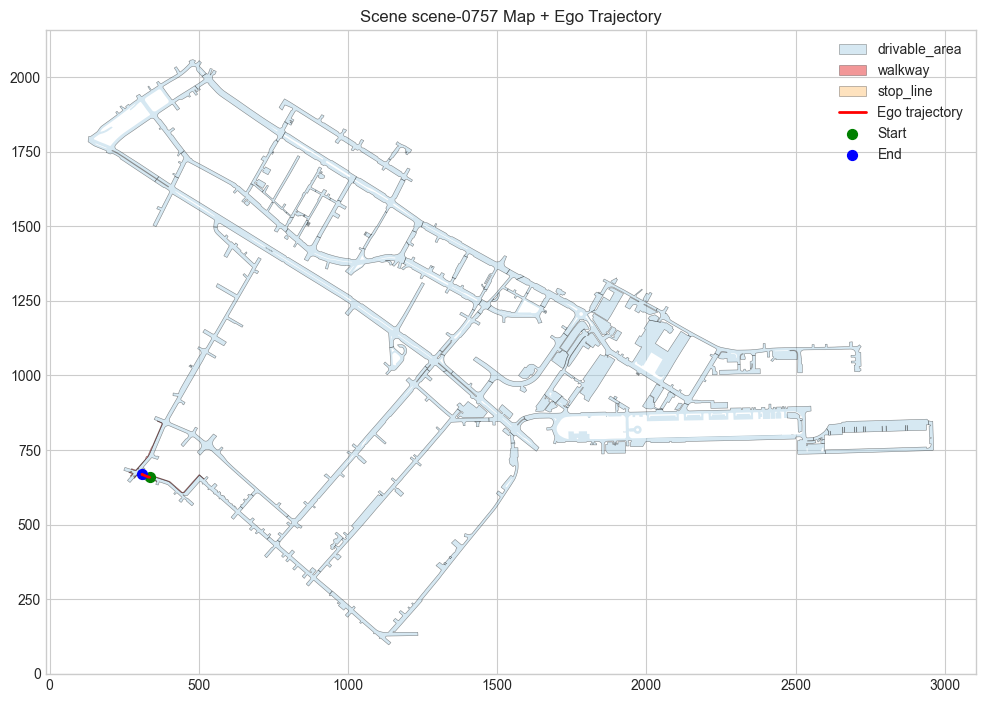

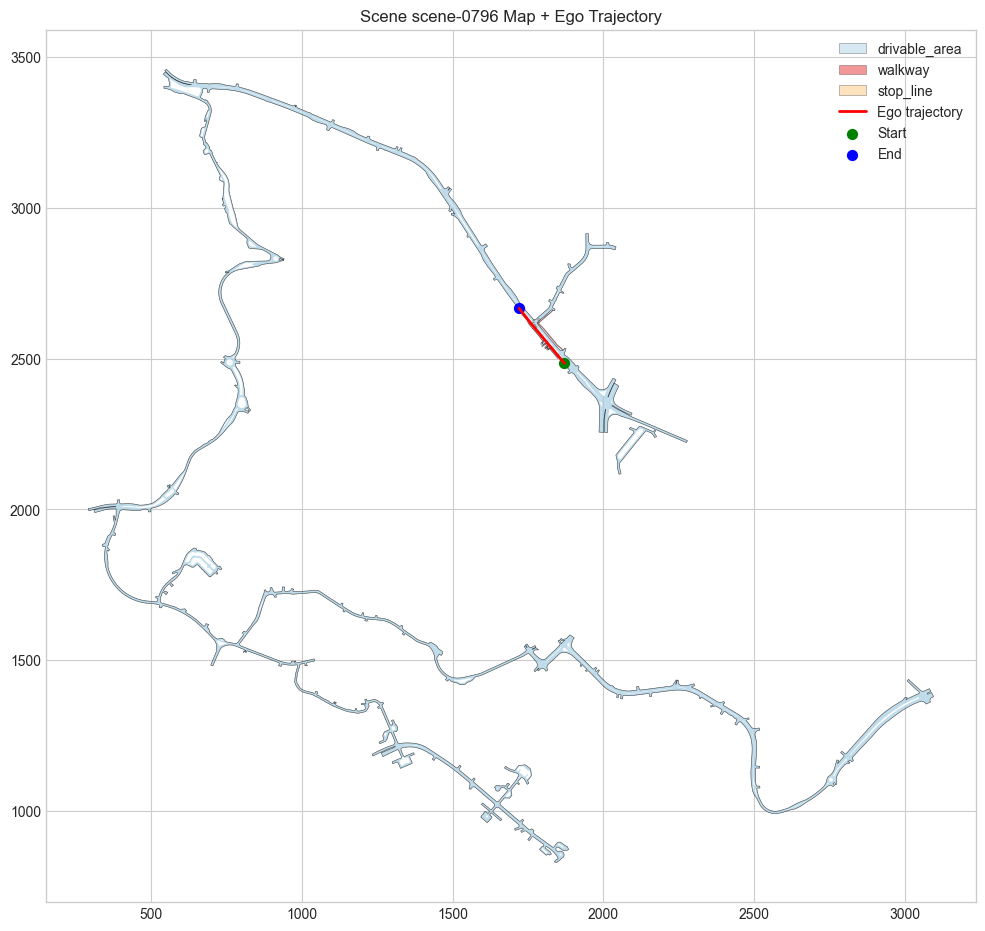

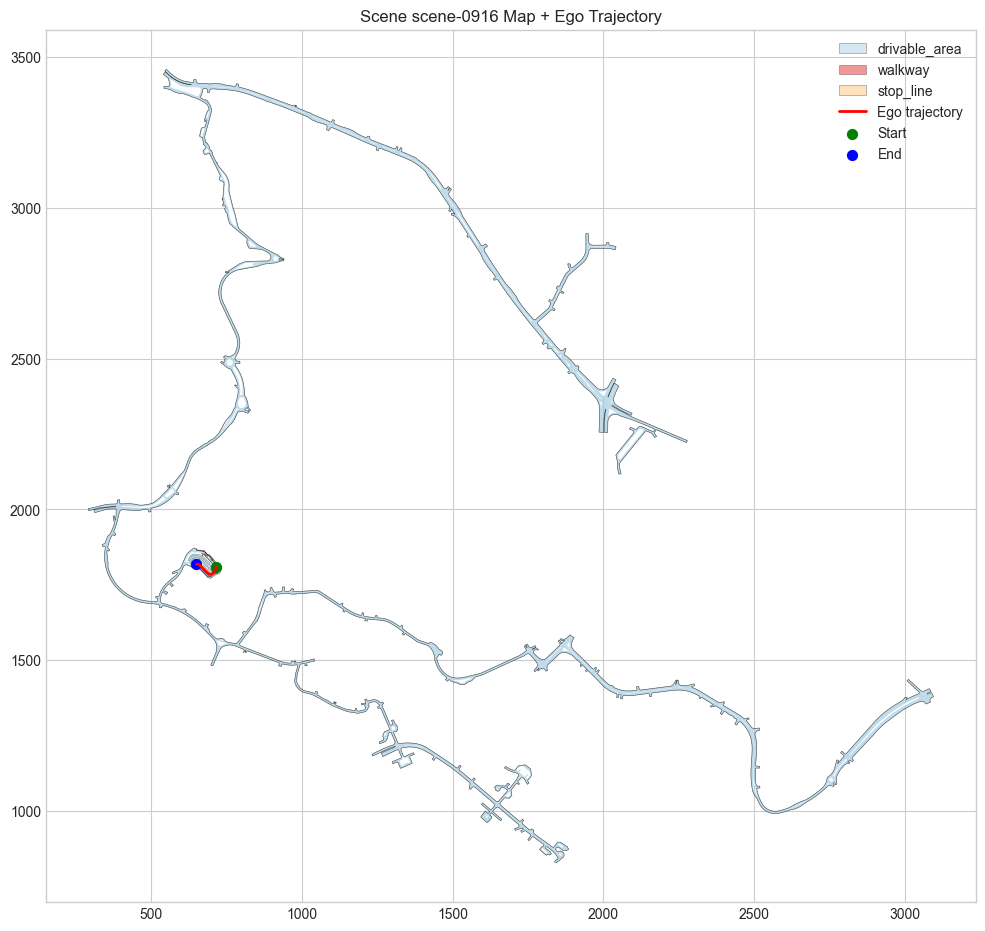

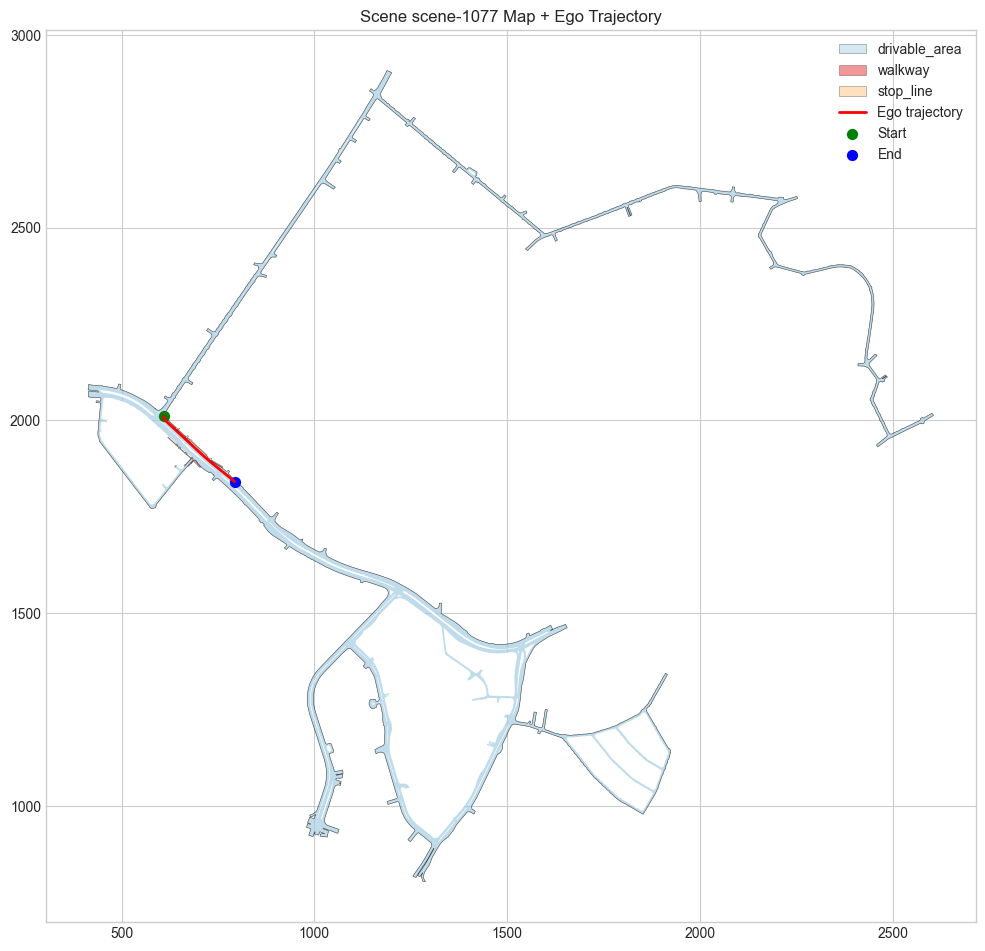

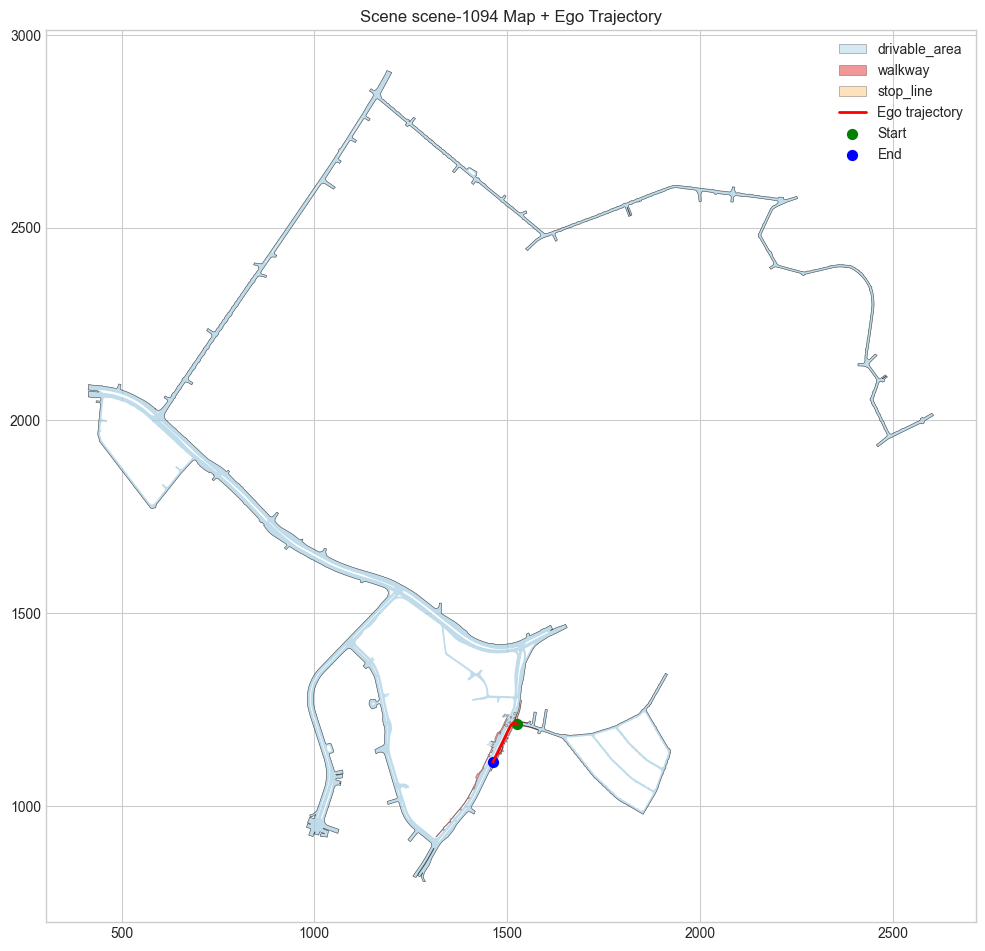

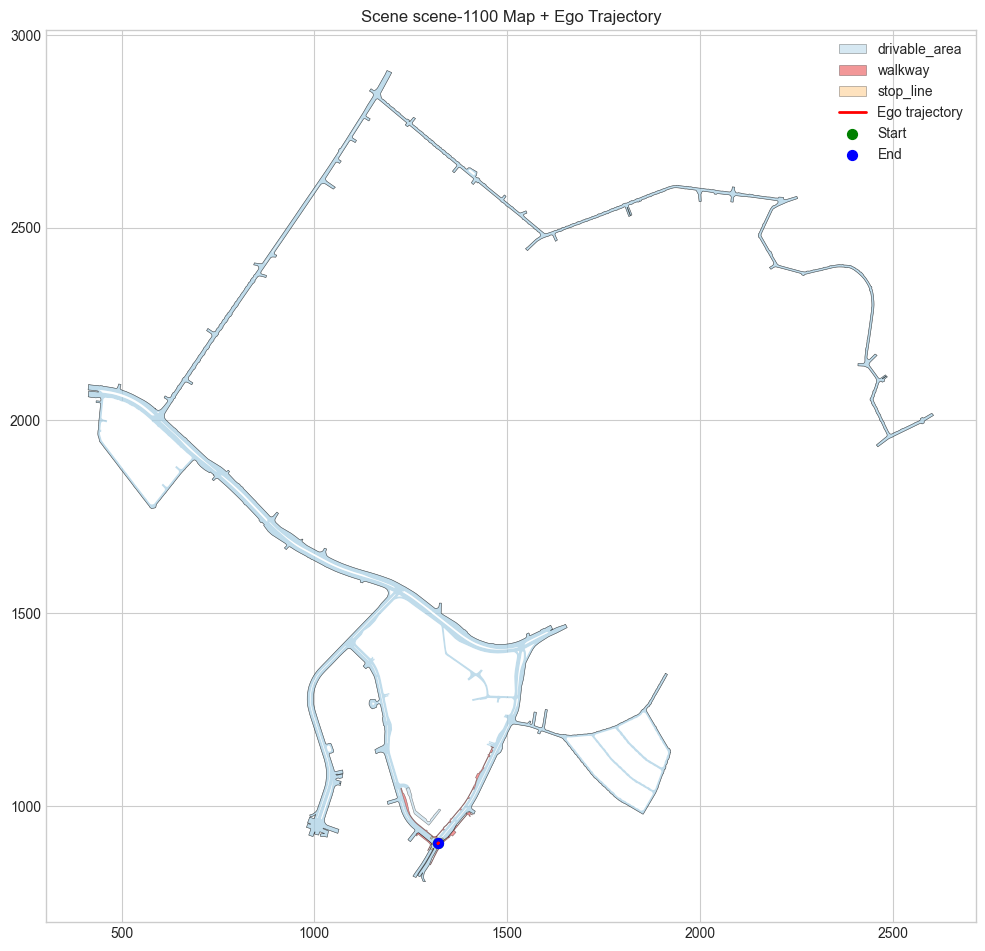

In [5]:
layers = ['drivable_area', 'walkway', 'stop_line']

for scene in nusc.scene[:10]:  # first 3 scenes for example
    log = nusc.get('log', scene['log_token'])
    map_name = log['location']
    nusc_map = NuScenesMap(dataroot=DATAROOT, map_name=map_name)
    
    # collect ego positions
    sample_token = scene['first_sample_token']
    ego_positions = []
    while sample_token:
        sample = nusc.get('sample', sample_token)
        sd = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
        ego = nusc.get('ego_pose', sd['ego_pose_token'])
        x, y = ego['translation'][:2]
        ego_positions.append([x, y])
        sample_token = sample['next']
    ego_positions = np.array(ego_positions)
    
    # Choose center = mean of ego trajectory
    cx, cy = ego_positions[:,0].mean(), ego_positions[:,1].mean()
    radius = 50  # meters around center
    
    fig, ax = plt.subplots(figsize=(12,12))
    polygons_found = 0
    
    for layer_name in layers:
        recs_dict = nusc_map.get_records_in_radius(cx, cy, radius, layer_names=[layer_name])
        record_tokens = recs_dict.get(layer_name, [])
        
        color = nusc_map.explorer.color_map.get(layer_name, 'gray')
        
        for record_token in record_tokens:
            record = nusc_map.get(layer_name, record_token)
            polygon_tokens = []
            if 'polygon_tokens' in record:
                polygon_tokens = record['polygon_tokens']
            elif 'polygon_token' in record:
                polygon_tokens = [record['polygon_token']]
            else:
                continue
            
            for poly_token in polygon_tokens:
                poly = nusc_map.extract_polygon(poly_token)
                if poly is None or poly.is_empty or not poly.is_valid:
                    continue
                polygons_found += 1
                
                # Exterior
                x_ext, y_ext = poly.exterior.xy
                patch_ext = MplPolygon(list(zip(x_ext, y_ext)),
                                        closed=True, fc=color, ec='black',
                                        lw=0.4, alpha=0.45, label=layer_name)
                ax.add_patch(patch_ext)
                
                # Interiors
                for hole in poly.interiors:
                    x_h, y_h = hole.xy
                    patch_hole = MplPolygon(list(zip(x_h, y_h)), closed=True,
                                            fc='white', ec='none', alpha=1.0)
                    ax.add_patch(patch_hole)
    
    # Plot ego trajectory
    ax.plot(ego_positions[:,0], ego_positions[:,1], 'r-', linewidth=2, label='Ego trajectory')
    ax.scatter(ego_positions[0,0], ego_positions[0,1], c='green', s=50, label='Start')
    ax.scatter(ego_positions[-1,0], ego_positions[-1,1], c='blue', s=50, label='End')
    
    # Legend
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys())
    
    ax.set_aspect('equal')
    plt.title(f"Scene {scene['name']} Map + Ego Trajectory")
    plt.show()

## Map-wise Aggregated Trajectory Visualization

To further validate scenario extraction, all ego trajectories belonging to the same map location are overlaid on a single semantic mant urban layouts.

Rendering map: singapore-onenorth


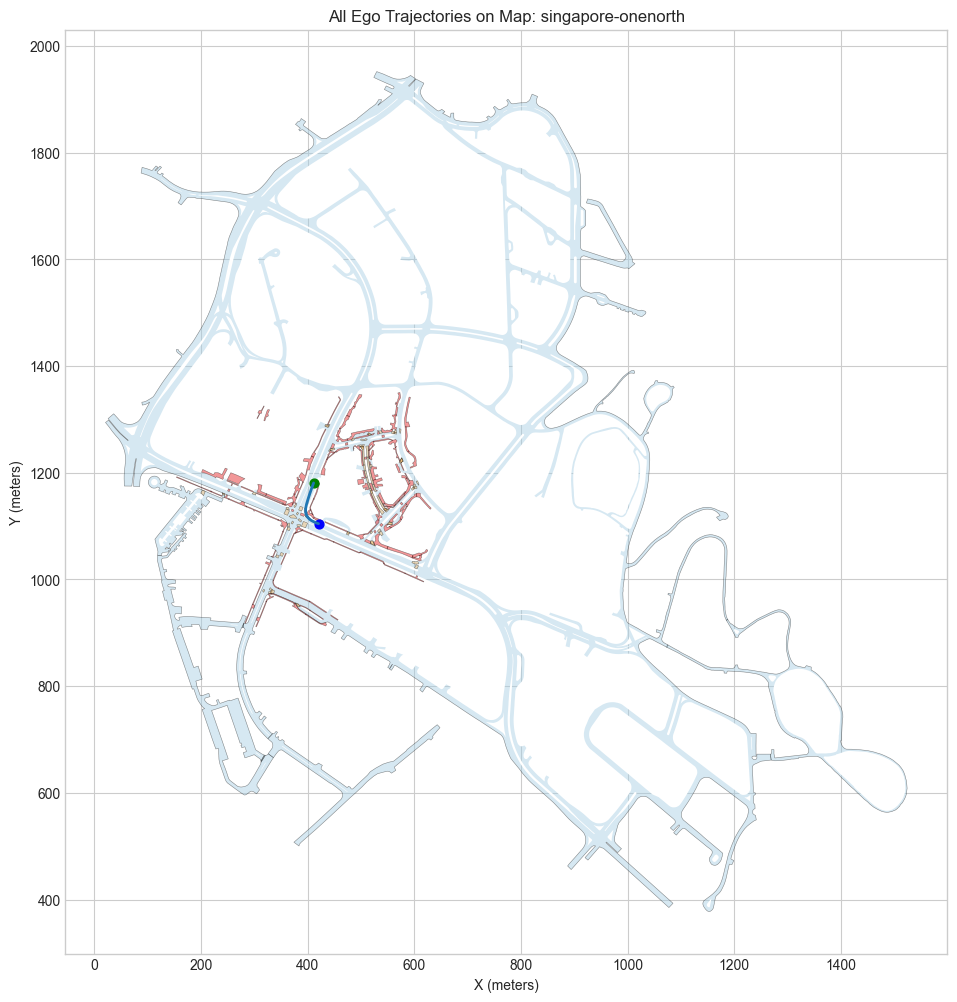

Rendering map: boston-seaport


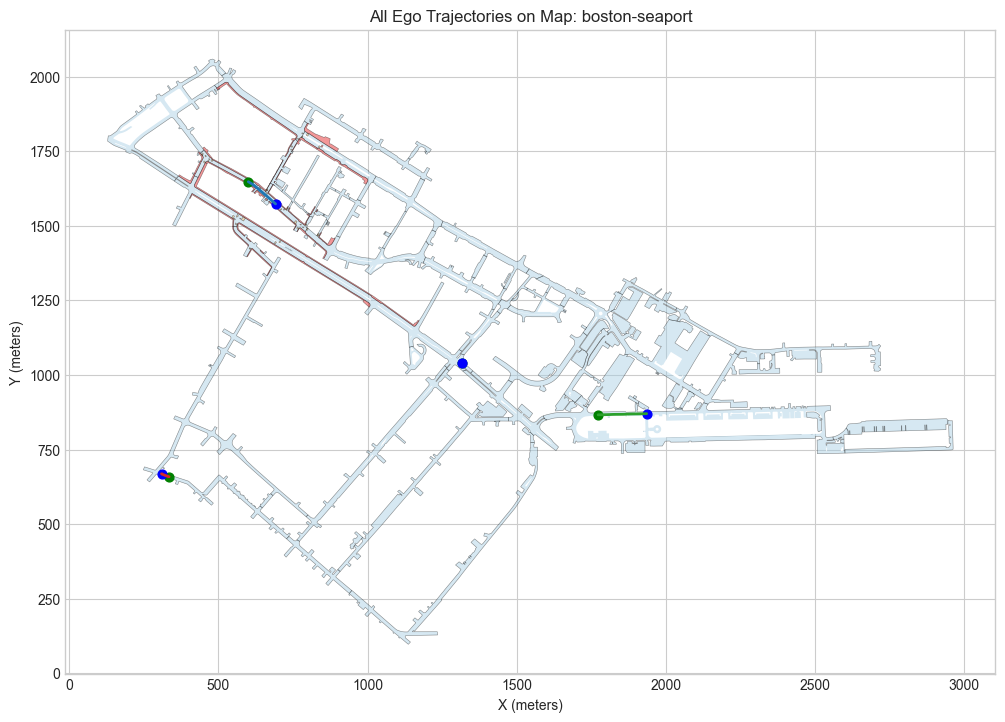

Rendering map: singapore-queenstown


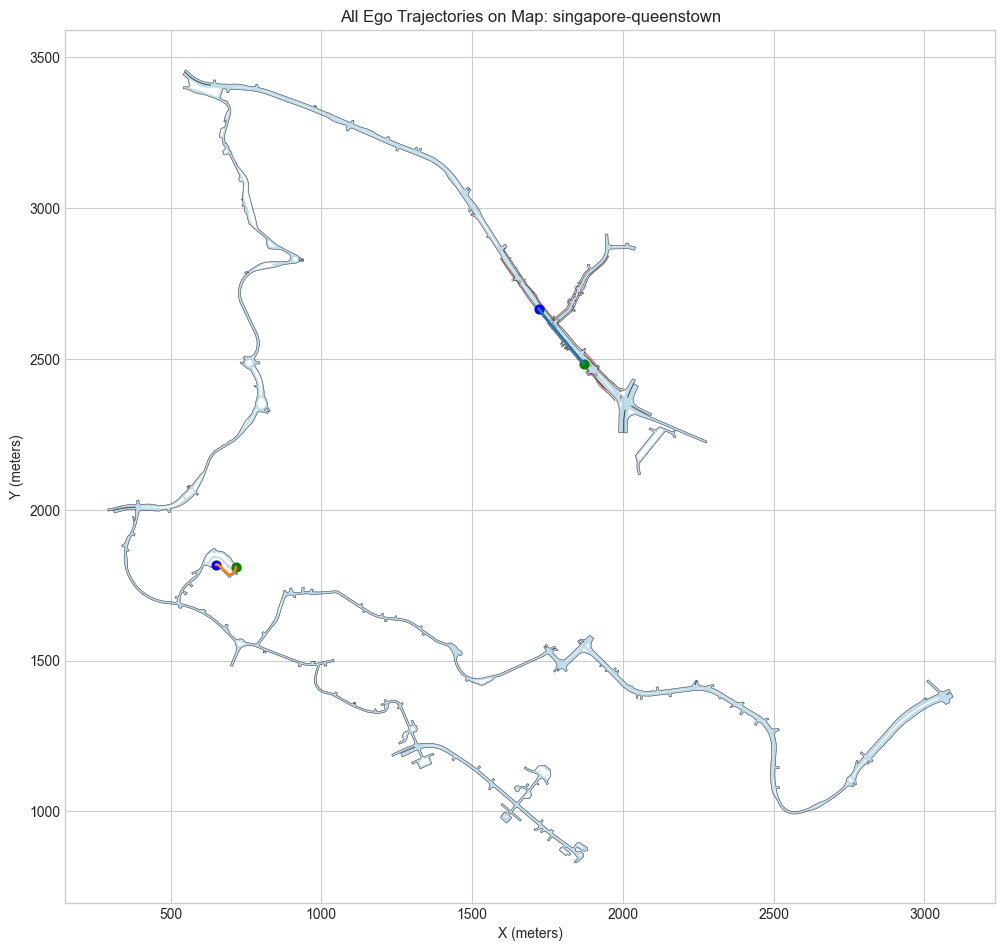

Rendering map: singapore-hollandvillage


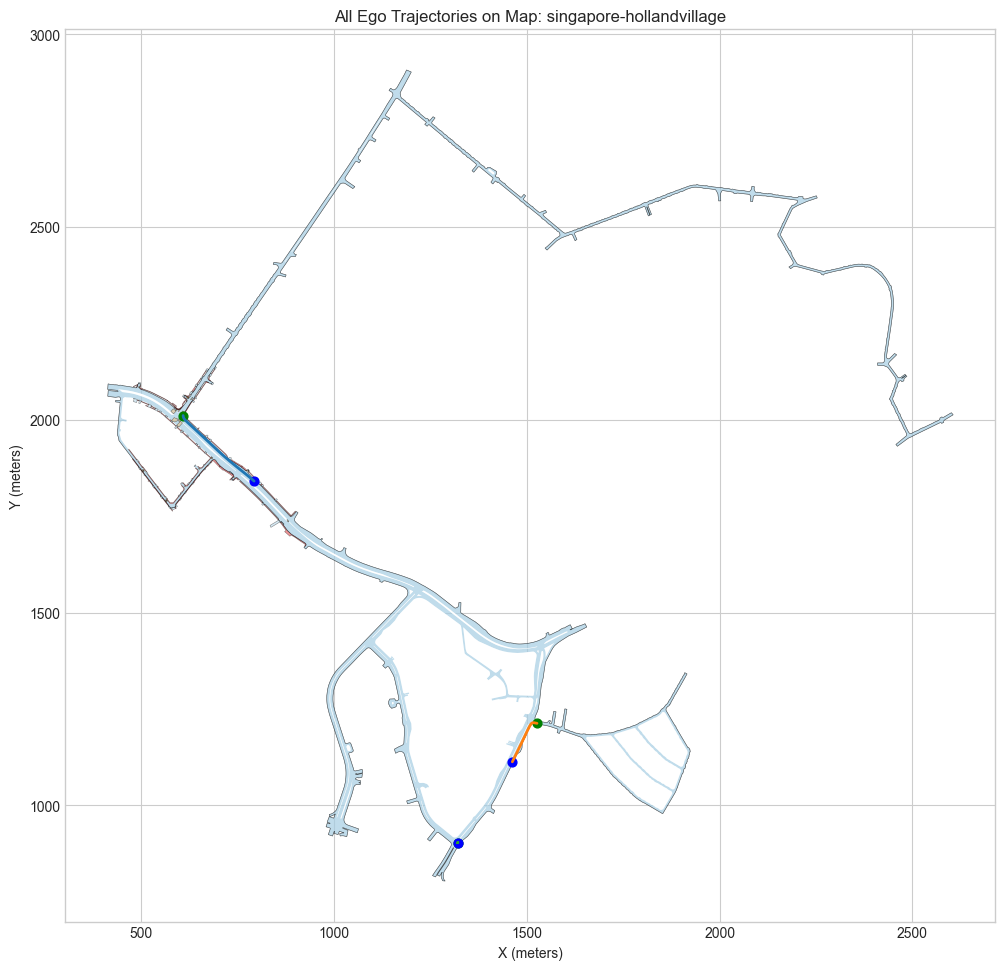

In [6]:
# Group scenes by map
map_scenes = defaultdict(list)
for scene in nusc.scene:
    log = nusc.get('log', scene['log_token'])
    map_name = log['location']
    map_scenes[map_name].append(scene)

# Layers to render
layers = ['drivable_area', 'walkway', 'stop_line']

# Loop over each map
for map_name, scenes in map_scenes.items():
    print("Rendering map:", map_name)
    nusc_map = NuScenesMap(dataroot=DATAROOT, map_name=map_name)
    
    fig, ax = plt.subplots(figsize=(12,12))
    polygons_found = 0
    
    # Render map polygons once
    # Use center = map center (roughly)
    # Or use first scene ego mean as center
    first_scene = scenes[0]
    sample_token = first_scene['first_sample_token']
    positions = []
    while sample_token:
        sample = nusc.get('sample', sample_token)
        sd = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
        ego = nusc.get('ego_pose', sd['ego_pose_token'])
        positions.append(ego['translation'][:2])
        sample_token = sample['next']
    positions = np.array(positions)
    cx, cy = positions[:,0].mean(), positions[:,1].mean()
    radius = 200  # meters
    
    for layer_name in layers:
        recs_dict = nusc_map.get_records_in_radius(cx, cy, radius, layer_names=[layer_name])
        record_tokens = recs_dict.get(layer_name, [])
        color = nusc_map.explorer.color_map.get(layer_name, 'gray')
        for record_token in record_tokens:
            record = nusc_map.get(layer_name, record_token)
            polygon_tokens = []
            if 'polygon_tokens' in record:
                polygon_tokens = record['polygon_tokens']
            elif 'polygon_token' in record:
                polygon_tokens = [record['polygon_token']]
            else:
                continue
            for poly_token in polygon_tokens:
                poly = nusc_map.extract_polygon(poly_token)
                if poly is None or poly.is_empty or not poly.is_valid:
                    continue
                polygons_found += 1
                x_ext, y_ext = poly.exterior.xy
                patch_ext = MplPolygon(list(zip(x_ext, y_ext)), closed=True, fc=color,
                                        ec='black', lw=0.4, alpha=0.45, label=layer_name)
                ax.add_patch(patch_ext)
                for hole in poly.interiors:
                    x_h, y_h = hole.xy
                    patch_hole = MplPolygon(list(zip(x_h, y_h)), closed=True,
                                            fc='white', ec='none', alpha=1.0)
                    ax.add_patch(patch_hole)
    
    # Overlay **all trajectories for this map**
    for scene in scenes:
        sample_token = scene['first_sample_token']
        ego_positions = []
        while sample_token:
            sample = nusc.get('sample', sample_token)
            sd = nusc.get('sample_data', sample['data']['LIDAR_TOP'])
            ego = nusc.get('ego_pose', sd['ego_pose_token'])
            ego_positions.append(ego['translation'][:2])
            sample_token = sample['next']
        ego_positions = np.array(ego_positions)
        ax.plot(ego_positions[:,0], ego_positions[:,1], '-', linewidth=2, label=f"{scene['name']} trajectory")
        ax.scatter(ego_positions[0,0], ego_positions[0,1], c='green', s=40)
        ax.scatter(ego_positions[-1,0], ego_positions[-1,1], c='blue', s=40)
    
    ax.set_aspect('equal')
    plt.title(f"All Ego Trajectories on Map: {map_name}")
    plt.xlabel("X (meters)")
    plt.ylabel("Y (meters)")
    # plt.legend(loc='upper right', fontsize=8)
    plt.show()

## Question 2 & 3: Feature Extraction and Handling Missing/Noisy Data

In this project, feature extraction and preprocessing were performed using the **ScenarioNet conversion utility** rather than implementing a custom feature engineering pipeline.

The following command was used to convert the nuScenes dataset into ScenarioNet-compatible driving scenarios:

```
python -m scenarionet.convert_nuscenes \
--database_path "D:\Assessement2\scenario_db" \
--split v1.0-mini \
--dataroot "D:\Assessement2\data\sets\nuscenes" \
--overwrite
```

### Explanation of the Conversion Process

This command automatically converts raw nuScenes driving scenes into structured simulation scenarios that can be used by the MetaDrive reinforcement learning environment.

The parameters used in the command perform the following functions:

* **--dataroot**
  Specifies the location of the original nuScenes dataset containing sensor recordings, annotations, and map information.

* **--split v1.0-mini**
  Uses the mini version of the nuScenes dataset, which contains a smaller subset of scenes suitable for experimentation and faster processing.

* **--database_path**
  Defines the directory where the converted ScenarioNet scenario database will be stored.

* **--overwrite**
  Allows existing scenario files in the target directory to be replaced during conversion.

### Feature Extraction

During conversion, ScenarioNet automatically extracts relevant driving features from the nuScenes dataset. These include:

* Vehicle position and orientation
* Speed and motion states
* Lane and road geometry
* Object and obstacle information
* Scenario metadata

These extracted features are organized into structured scenario files that can be directly used by the MetaDrive simulation environment for reinforcement learning training.

### Handling Missing or Noisy Data

The nuScenes dataset may contain incomplete sensor readings or noise due to real-world data collection conditions. ScenarioNet addresses these i. aructured representation of the driving environment.

### Limitation

In this project, feature extraction and noise handling were performed using the built-in ScenarioNet conversion tools rather than implementing custom preprocessing methods. While this simplifies the workflow, it limits direct control over how specific features are selected or how noise filtering is performed.


In [ ]:
import sys
! "{sys.executable}" -m scenarionet.convert_nuscenes --database_path "D:\Assessement2\scenario_db" --split v1.0-mini --dataroot "D:\Assessement2\data\sets\nuscenes" --overwrite

## Question 5 & 6: Reward Function Design and Incorporation of Penalties

A custom reward function was implemented to guide the reinforcement learning agent toward safe and efficient driving behavior. The reward function evaluates the vehicle's behavior at every simulation step and assigns positive or negative rewards depending on its actions.

The reward components are designed as follows:

### 1. Progress Reward

```
progress_reward = vehicle.speed * 0.05
```

This term encourages the vehicle to move forward. Higher speed results in a higher reward, motivating the agent to maintain forward progress rather than remaining stationary.

### 2. Steering Penalty

```
steering_penalty = -0.02 * abs(vehicle.steering)
```

Large steering angles indicate abrupt or unstable driving behavior. This penalty discourages aggressive steering and encourages smoother vehicle control.

### 3. Collision Penalty

```
crash_penalty = -10
```

A large negative reward is assigned when the vehicle collides with other vehicles, objects, buildings, pedestrians, or sidewalks. This strongly discourages unsafe driving behaviors.

### 4. Lane Departure Penalty

The vehicle's lateral distance from the center of the lane is calculated using:

```
_, lateral = vehicle.lane.local_coordinates(vehicle.position)
```

The penalty is defined as:

```
lane_penalty = -0.02 * abs(lateral)
```

This discourages the vehicle from drifting away from the center of its lane and promotes stable lane-following behavior.

### Total Reward

The total reward is calculated as the sum of all components:

```
total_reward = progress_reward + steering_penalty + crash_penalty + lane_penalty
```

This reward structure encourages the agent to:

* Maintain forward progress
* Stay near the center of the lane
* Avoid collisions
* Drive smoothly without sudden steering


In [7]:
class CustomScenarioEnv(ScenarioEnv):

    def reward_function(self, vehicle_id: str):
        vehicle = self.agents[vehicle_id]

        progress_reward = vehicle.speed * 0.05
        steering_penalty = -0.02 * abs(vehicle.steering)
        crash_penalty = -10 if ( vehicle.crash_vehicle or vehicle.crash_object or vehicle.crash_building or vehicle.crash_human or vehicle.crash_sidewalk) else 0

        # 4️⃣ Lane departure penalty (true centerline offset)
        lane_penalty = 0.0        
        if hasattr(vehicle, "lane") and vehicle.lane is not None:
            try:
                # Lateral distance from true lane center
                _, lateral = vehicle.lane.local_coordinates(vehicle.position)
                lane_penalty = -0.02 * abs(lateral)         
                
            except Exception:
                # Safe fallback — don't crash the reward function
                pass

        
        total_reward = progress_reward + steering_penalty + crash_penalty + lane_penalty 
        
        reward_info = {
            "progress_reward": progress_reward,
            "steering_penalty": steering_penalty,
            "crash_penalty": crash_penalty,
            "lane_penalty": lane_penalty,

        }

        self._step_counter = getattr(self, '_step_counter', 0) + 1

        if self._step_counter % 10000 == 0:
            print(f"Step {self._step_counter:5d} → {reward_info}")


        return total_reward, reward_info
        

## Simulation Environment Setup

The reinforcement learning environment is created using a custom environment that extends the ScenarioEnv class.

Key parameters used in the environment configuration are:

### data_directory

```
"data_directory": "D:/Assessement2/scenario_db"
```

This directory contains the driving scenarios generated from the nuScenes dataset using the ScenarioNet conversion process.

### num_scenarios

```
"num_scenarios": 5
```

This parameter specifies that five scenarios from the dataset will be used during training. Each episode randomly samples from these scenarios, allowing the agent to experience different driving situations.

### horizon

```
"horizon": 500
```

The horizon defines the maximum number of simulation steps per episode. If the agent does not crash or terminate earlier, the episode ends after 500 steps.

### use_render

```
"use_render": False
```

Rendering is disabled during training to improve computational efficiency. This allows the training process to run faster since graphical visualization is not required.


In [8]:
env = CustomScenarioEnv({
    "data_directory": "D:/Assessement2/scenario_db",
    "num_scenarios": 5,
    "horizon": 500,
    "use_render": False,
})

[INFO] Environment: CustomScenarioEnv
[INFO] MetaDrive version: 0.4.3
[INFO] Sensors: [lidar: Lidar(), side_detector: SideDetector(), lane_line_detector: LaneLineDetector()]
[INFO] Render Mode: none
[INFO] Horizon (Max steps per agent): 500


## State Representation (Observation Space)

The observation space defines the information that the reinforcement learning agent receives from the environment at each timestep.

```
print(env.observation_space)
print(env.observation_space.shape)
```

The output shows the structure and dimensionality of the state vector used by the RL agent. These observations typically include:

* Vehicle position
* Vehicle speed
* Relative positions of nearby vehicles
* Lane information
* Road geometry
* Other environmental features

These features provide the agent with sufficient information to understand its surroundings and make appropriate ing policy network.


In [9]:
print(env.observation_space)
print(env.observation_space.shape)

Box(-0.0, 1.0, (161,), float32)
(161,)


## Action Representation Used in This Study

This project uses a **continuous action space** because it enables smoother steering control and more realistic acceleration behavior, which are essential for training autonomous driving agents.


The action space defines the set of actions that the reinforcement learning agent can take at each timestep.

```
print(env.action_space)
```

In this environment, the agent uses a **continuous action space** consisting of two control variables:

1. **Steering**

   * Controls the direction of the vehicle
   * Range between -1 and 1 (-1 = full left, +1 = full right)

2. **Throttle/Brake**

   * Controls the acceleration and braking of the vehicle
   * Range between -1 and 1 (-1 = full brake, +1 = full throttle)

Random samples from the action space are generated to illustrate the possible control inputs:

```
env.action_space.sample()
```

This confirms that the agent operates in a continuous control setting, similar to real-world autonomous driving systems where steering and acceleration are continuous rather than discrete decisions.


### Continuous vs Discrete Action Spaces

In reinforcement learning for autonomous driving, the agent's actions can be represented using either **continuous** or **discrete** action spaces.

#### Continuous Action Space

In a continuous action space, the agent can output any value within a given range. This allows fine-grained control of vehicle dynamics.

In this project, the action space is continuous

This representation closely resembles real-world vehicle control systems where steering angle and throttle input vary smoothly.

Continuous action spaces are commonly used in autonomous driving because they allow smoother and more realistic control of the vehicle.

#### Discrete Action Space

In a discrete action space, the agent selects from a predefined set of actions. For example:

* Turn left
* Turn right
* Go straight
* Accelerate
* Brake

Discrete actions simplify the learning process but provide less precise control over vehicle behavior.

For example, a discrete action representation for driving could be:

| Action ID | Meaning     |
| --------- | ----------- |
| 0         | Turn Left   |
| 1         | Turn Right  |
| 2         | Go Straight |
| 3         | Accelerate  |
| 4         | Brake       |

While discrete actions are easier to learn, they are less suitable for realistic vehicle control compared to continuous actions.

In [10]:
print("Action space details:", env.action_space)

print("Random actions examples:")
for _ in range(10):
    a = env.action_space.sample()
    print(f"Steering: {a[0]:.3f} | Throttle/Brake: {a[1]:.3f}")

Action space details: Box(-1.0, 1.0, (2,), float32)
Random actions examples:
Steering: 0.467 | Throttle/Brake: 0.966
Steering: -0.571 | Throttle/Brake: -0.428
Steering: 0.477 | Throttle/Brake: 0.281
Steering: 0.753 | Throttle/Brake: 0.259
Steering: 0.780 | Throttle/Brake: 0.762
Steering: -0.845 | Throttle/Brake: -0.092
Steering: 0.245 | Throttle/Brake: 0.835
Steering: -0.155 | Throttle/Brake: 0.108
Steering: 0.412 | Throttle/Brake: 0.484
Steering: 0.362 | Throttle/Brake: -0.104


# Train Model

In [ ]:
from stable_baselines3 import PPO

model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=3e-4,
)

model.learn(total_timesteps=300000)

# Save and Reload Model

In [ ]:
model.save("ppo_nuscenes_agent_300000version5")

In [ ]:
del model

In [11]:
env.close()

In [11]:
model = PPO.load("ppo_nuscenes_agent_300000version5")

D:\New folder (4)\RL_Projects\rl_env\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


# Evaluate Model

### Performance Assessment Discussion – Scenario-Specific Behavior

**Observation**:  
- When intersection scenes are excluded (only highway/straight-lane scenes evaluated): very high success rate, low off-road rate, smooth speed/steering curves, high average reward.  
- When intersections are included: success rate drops to 0, off-road rate rises sharply.

**Additional data handling note**:
- Two scenes with **close to zero ego vehicle displacement** (<1 m total movement) were excluded from evaluation (via conditional skip). These scenes cause degenerate 1-step episodes (immediate termination), which collapse averaged time-step plots and distort aggregate metrics.
- **Ideally these scenes should also have been excluded from training**. Including near-static scenes during training teaches the agent to produce minimal or no movement in some cases, which harms generalization to normal driving (especially intersections/turns where active maneuvering is required).


**Explanation**:
- Training data contained **only 1 intersection with a turn** → the agent had very limited exposure to turning maneuvers, yielding, traffic light handling, and multi-agent interactions typical of intersections.
- The reward function emphasizes **progress/speed**, **penalizes lane deviation and steering magnitude** → this works excellently for highway keeping but **discourages necessary lateral movement and sharp steering** required for turns.
- Intersections require dense, scenario-specific rewards (e.g., positive bonus for correct lane change, yielding, or completing turn) and/or hierarchical policies — a simple shaped reward struggles here.
- High off-road rate in intersections likely results from the agent attempting to stay too straight (to minimize steering/lane penalties) → eventually departs lane or collides.

## All Scenario

[INFO] Environment: CustomScenarioEnv
[INFO] MetaDrive version: 0.4.3
[INFO] Sensors: [lidar: Lidar(), side_detector: SideDetector(), lane_line_detector: LaneLineDetector()]
[INFO] Render Mode: none
[INFO] Horizon (Max steps per agent): 500
[INFO] Assets version: 0.4.3
[INFO] Known Pipes: wglGraphicsPipe
[INFO] Start Scenario Index: 0, Num Scenarios : 10



===== RL AGENT PERFORMANCE =====
Episodes run: 23
Average episode reward: 23.846970318723493
Average standard deviation of reward 33.6454832172722
Average episode length: 50.04347826086956
Success rate: 21.73913043478261 %
Collision rate: 13.043478260869565 %
Off-road rate: 78.26086956521739 %
Average speed: 12.146318538556807
Average steering magnitude: 0.24410936


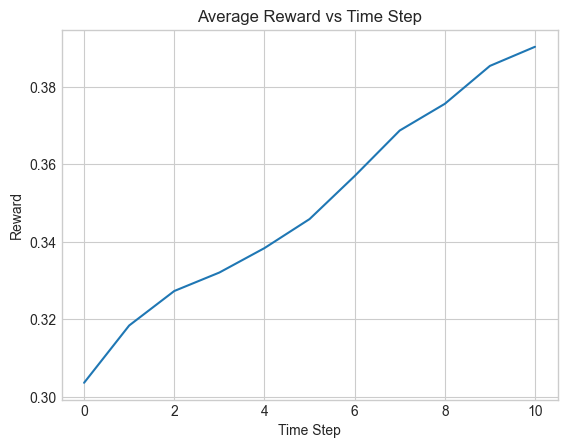

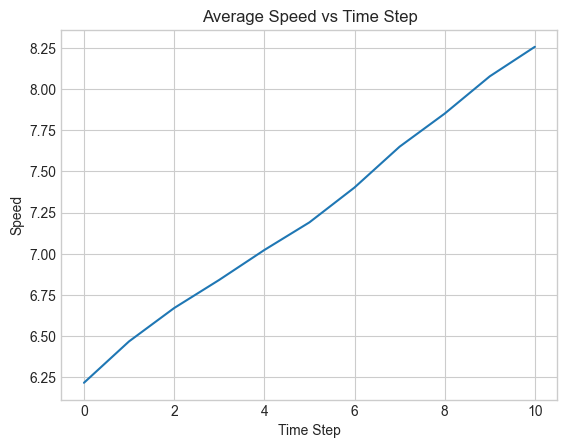

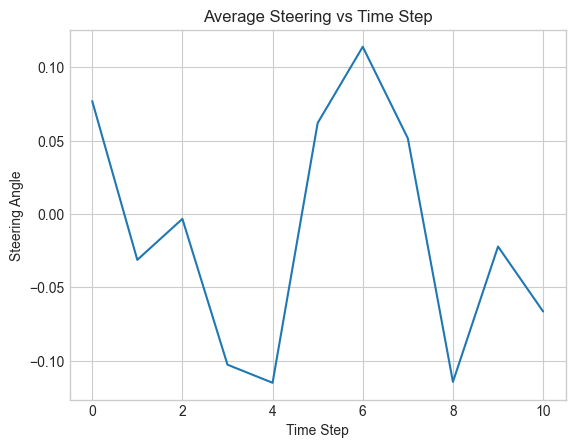

In [12]:
# ------------------------------
# Set up evaluation environment
# ------------------------------
eval_env = CustomScenarioEnv({
    "data_directory": "D:/Assessement2/scenario_db",
    "num_scenarios": 10,       
    "horizon": 500,
    "use_render": False
})

num_episodes = 30  

# ------------------------------
# Storage for metrics
# ------------------------------
all_rewards = []
all_speeds = []
all_steerings = []
episode_rewards = []
episode_lengths = []
episode_success = []
episode_collisions = []
episode_offroad = []

# ------------------------------
# Run evaluation episodes
# ------------------------------
for ep in range(num_episodes):

    obs, _ = eval_env.reset()
    
    current_index = eval_env.current_seed
    if current_index in (2, 9): #Skip problematic scene
        continue

    done = False
    terminated = False
    truncated = False

    rewards = []
    speeds = []
    steerings = []

    collision = False
    offroad = False
    success = False

    while not (done or truncated):

        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(action)

        done = terminated or truncated

        # Safe vehicle access
        agents = eval_env.engine.agent_manager.active_agents
        if len(agents) == 0:
            break
        vehicle = list(agents.values())[0]

        rewards.append(reward)
        speeds.append(vehicle.speed)
        steerings.append(vehicle.steering)

        # Safety / success flags
        if info.get("crash_vehicle", False) or info.get("crash_object", False) or \
           info.get("crash_building", False) or info.get("crash_human", False) or \
           info.get("crash_sidewalk", False):
            collision = True

        if info.get("out_of_road", False):
            offroad = True

        if info.get("arrive_dest", False):
            success = True

    if len(rewards) < 0:
        continue  # skip empty episodes

    # Store episode metrics
    all_rewards.append(rewards)
    all_speeds.append(speeds)
    all_steerings.append(steerings)

    episode_rewards.append(sum(rewards))
    episode_lengths.append(len(rewards))
    episode_success.append(success)
    episode_collisions.append(collision)
    episode_offroad.append(offroad)

eval_env.close()

# ------------------------------
# Convert to Average Curves
# ------------------------------
min_len = min(len(r) for r in all_rewards)

avg_rewards = np.mean([r[:min_len] for r in all_rewards], axis=0)
avg_speeds = np.mean([s[:min_len] for s in all_speeds], axis=0)
avg_steerings = np.mean([st[:min_len] for st in all_steerings], axis=0)

# ------------------------------
# Print Episode-Level Summaries
# ------------------------------
print("\n===== RL AGENT PERFORMANCE =====")
print("Episodes run:", len(episode_rewards))
print("Average episode reward:", np.mean(episode_rewards))
print("Average standard deviation of reward", np.std(episode_rewards))
print("Average episode length:", np.mean(episode_lengths))
print("Success rate:", np.mean(episode_success) * 100, "%")
print("Collision rate:", np.mean(episode_collisions) * 100, "%")
print("Off-road rate:", np.mean(episode_offroad) * 100, "%")
print("Average speed:", np.mean([v for ep in all_speeds for v in ep]))
print("Average steering magnitude:", np.mean([abs(v) for ep in all_steerings for v in ep]))


# ------------------------------
# Plot Metrics
# ------------------------------
plt.figure()
plt.plot(avg_rewards)
plt.title("Average Reward vs Time Step")
plt.xlabel("Time Step")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(avg_speeds)
plt.title("Average Speed vs Time Step")
plt.xlabel("Time Step")
plt.ylabel("Speed")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(avg_steerings)
plt.title("Average Steering vs Time Step")
plt.xlabel("Time Step")
plt.ylabel("Steering Angle")
plt.grid(True)
plt.show()

## Scenario : Highway only

[INFO] Environment: CustomScenarioEnv
[INFO] MetaDrive version: 0.4.3
[INFO] Sensors: [lidar: Lidar(), side_detector: SideDetector(), lane_line_detector: LaneLineDetector()]
[INFO] Render Mode: none
[INFO] Horizon (Max steps per agent): 500
[INFO] Assets version: 0.4.3
[INFO] Known Pipes: wglGraphicsPipe
[INFO] Start Scenario Index: 0, Num Scenarios : 10



===== RL AGENT PERFORMANCE =====
Episodes run: 16
Average episode reward: 52.64099092348533
Average standard deviation of reward 26.921786853390742
Average episode length: 73.75
Success rate: 37.5 %
Collision rate: 0.0 %
Off-road rate: 62.5 %
Average speed: 14.834480317924607
Average steering magnitude: 0.2533717


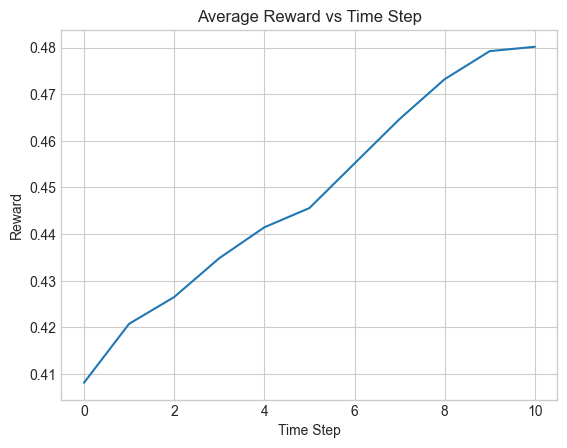

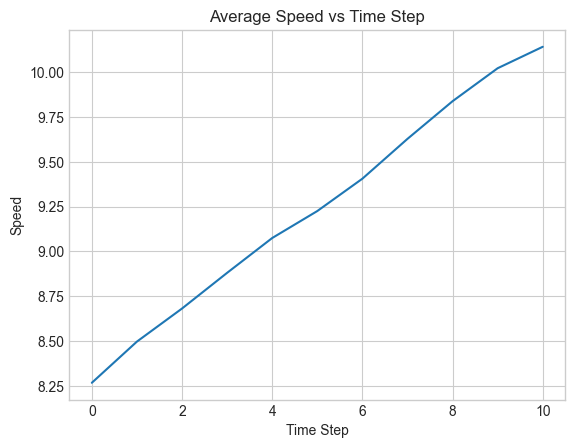

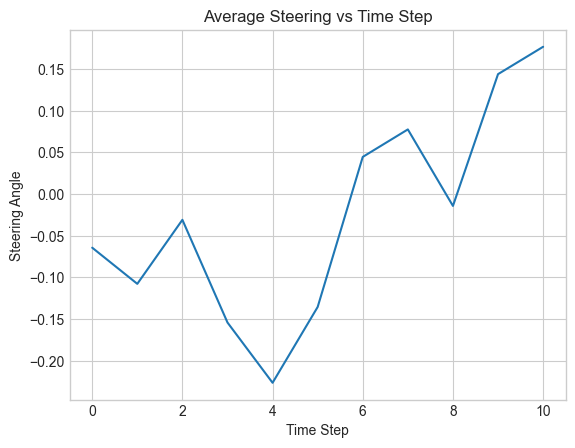

In [13]:
# ------------------------------
# Set up evaluation environment
# ------------------------------
eval_env = CustomScenarioEnv({
    "data_directory": "D:/Assessement2/scenario_db",
    "num_scenarios": 10,       
    "horizon": 500,
    "use_render": False
})

num_episodes = 30  

# ------------------------------
# Storage for metrics
# ------------------------------
all_rewards = []
all_speeds = []
all_steerings = []
episode_rewards = []
episode_lengths = []
episode_success = []
episode_collisions = []
episode_offroad = []

# ------------------------------
# Run evaluation episodes
# ------------------------------
for ep in range(num_episodes):

    obs, _ = eval_env.reset()
    
    current_index = eval_env.current_seed
    if current_index in (2, 9): #Skip problematic scene
        continue
    if current_index in (0,6,8): #Skip intersections
        continue

    done = False
    terminated = False
    truncated = False

    rewards = []
    speeds = []
    steerings = []

    collision = False
    offroad = False
    success = False

    while not (done or truncated):

        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(action)

        done = terminated or truncated

        # Safe vehicle access
        agents = eval_env.engine.agent_manager.active_agents
        if len(agents) == 0:
            break
        vehicle = list(agents.values())[0]

        rewards.append(reward)
        speeds.append(vehicle.speed)
        steerings.append(vehicle.steering)

        # Safety / success flags
        if info.get("crash_vehicle", False) or info.get("crash_object", False) or \
           info.get("crash_building", False) or info.get("crash_human", False) or \
           info.get("crash_sidewalk", False):
            collision = True

        if info.get("out_of_road", False):
            offroad = True

        if info.get("arrive_dest", False):
            success = True

    if len(rewards) < 0:
        continue  # skip empty episodes

    # Store episode metrics
    all_rewards.append(rewards)
    all_speeds.append(speeds)
    all_steerings.append(steerings)

    episode_rewards.append(sum(rewards))
    episode_lengths.append(len(rewards))
    episode_success.append(success)
    episode_collisions.append(collision)
    episode_offroad.append(offroad)

eval_env.close()

# ------------------------------
# Convert to Average Curves
# ------------------------------
min_len = min(len(r) for r in all_rewards)

avg_rewards = np.mean([r[:min_len] for r in all_rewards], axis=0)
avg_speeds = np.mean([s[:min_len] for s in all_speeds], axis=0)
avg_steerings = np.mean([st[:min_len] for st in all_steerings], axis=0)

# ------------------------------
# Print Episode-Level Summaries
# ------------------------------
print("\n===== RL AGENT PERFORMANCE =====")
print("Episodes run:", len(episode_rewards))
print("Average episode reward:", np.mean(episode_rewards))
print("Average standard deviation of reward", np.std(episode_rewards))
print("Average episode length:", np.mean(episode_lengths))
print("Success rate:", np.mean(episode_success) * 100, "%")
print("Collision rate:", np.mean(episode_collisions) * 100, "%")
print("Off-road rate:", np.mean(episode_offroad) * 100, "%")
print("Average speed:", np.mean([v for ep in all_speeds for v in ep]))
print("Average steering magnitude:", np.mean([abs(v) for ep in all_steerings for v in ep]))


# ------------------------------
# Plot Metrics
# ------------------------------
plt.figure()
plt.plot(avg_rewards)
plt.title("Average Reward vs Time Step")
plt.xlabel("Time Step")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(avg_speeds)
plt.title("Average Speed vs Time Step")
plt.xlabel("Time Step")
plt.ylabel("Speed")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(avg_steerings)
plt.title("Average Steering vs Time Step")
plt.xlabel("Time Step")
plt.ylabel("Steering Angle")
plt.grid(True)
plt.show()

## Scenario: Intersections only

[INFO] Environment: CustomScenarioEnv
[INFO] MetaDrive version: 0.4.3
[INFO] Sensors: [lidar: Lidar(), side_detector: SideDetector(), lane_line_detector: LaneLineDetector()]
[INFO] Render Mode: none
[INFO] Horizon (Max steps per agent): 500
[INFO] Assets version: 0.4.3
[INFO] Known Pipes: wglGraphicsPipe
[INFO] Start Scenario Index: 0, Num Scenarios : 10



===== RL AGENT PERFORMANCE =====
Episodes run: 9
Average episode reward: -0.4130885467698186
Average standard deviation of reward 24.318266113226095
Average episode length: 38.0
Success rate: 0.0 %
Collision rate: 33.33333333333333 %
Off-road rate: 100.0 %
Average speed: 7.31230777648491
Average steering magnitude: 0.25877002


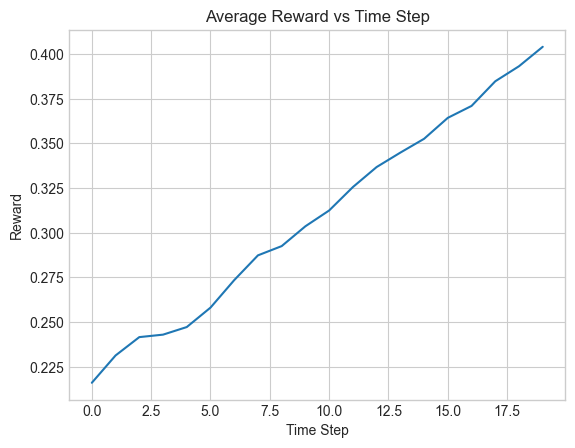

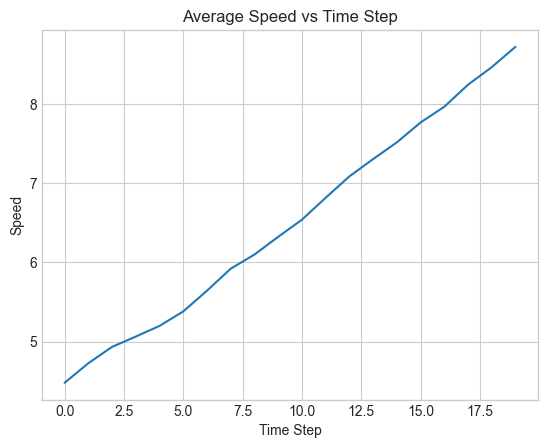

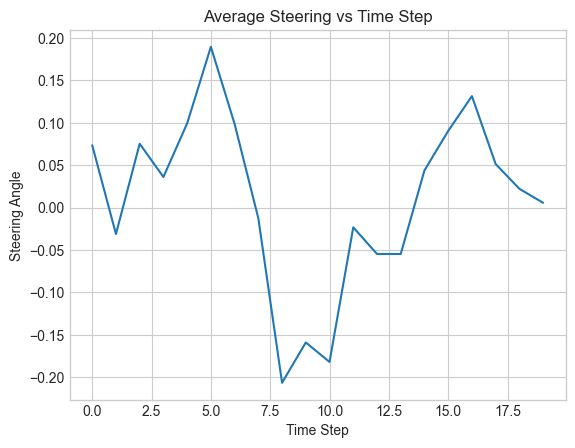

In [14]:
# ------------------------------
# Set up evaluation environment
# ------------------------------
eval_env = CustomScenarioEnv({
    "data_directory": "D:/Assessement2/scenario_db",
    "num_scenarios": 10,       
    "horizon": 500,
    "use_render": False
})

num_episodes = 30  

# ------------------------------
# Storage for metrics
# ------------------------------
all_rewards = []
all_speeds = []
all_steerings = []
episode_rewards = []
episode_lengths = []
episode_success = []
episode_collisions = []
episode_offroad = []

# ------------------------------
# Run evaluation episodes
# ------------------------------
for ep in range(num_episodes):

    obs, _ = eval_env.reset()
    
    current_index = eval_env.current_seed
    if current_index in (2, 9): #Skip problematic scene
        continue

    if current_index in (1, 3, 4, 5, 7): #Skip problematic scene
        continue

    done = False
    terminated = False
    truncated = False

    rewards = []
    speeds = []
    steerings = []

    collision = False
    offroad = False
    success = False

    while not (done or truncated):

        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(action)

        done = terminated or truncated

        # Safe vehicle access
        agents = eval_env.engine.agent_manager.active_agents
        if len(agents) == 0:
            break
        vehicle = list(agents.values())[0]

        rewards.append(reward)
        speeds.append(vehicle.speed)
        steerings.append(vehicle.steering)

        # Safety / success flags
        if info.get("crash_vehicle", False) or info.get("crash_object", False) or \
           info.get("crash_building", False) or info.get("crash_human", False) or \
           info.get("crash_sidewalk", False):
            collision = True

        if info.get("out_of_road", False):
            offroad = True

        if info.get("arrive_dest", False):
            success = True

    if len(rewards) < 0:
        continue  # skip empty episodes

    # Store episode metrics
    all_rewards.append(rewards)
    all_speeds.append(speeds)
    all_steerings.append(steerings)

    episode_rewards.append(sum(rewards))
    episode_lengths.append(len(rewards))
    episode_success.append(success)
    episode_collisions.append(collision)
    episode_offroad.append(offroad)

eval_env.close()

# ------------------------------
# Convert to Average Curves
# ------------------------------
min_len = min(len(r) for r in all_rewards)

avg_rewards = np.mean([r[:min_len] for r in all_rewards], axis=0)
avg_speeds = np.mean([s[:min_len] for s in all_speeds], axis=0)
avg_steerings = np.mean([st[:min_len] for st in all_steerings], axis=0)

# ------------------------------
# Print Episode-Level Summaries
# ------------------------------
print("\n===== RL AGENT PERFORMANCE =====")
print("Episodes run:", len(episode_rewards))
print("Average episode reward:", np.mean(episode_rewards))
print("Average standard deviation of reward", np.std(episode_rewards))
print("Average episode length:", np.mean(episode_lengths))
print("Success rate:", np.mean(episode_success) * 100, "%")
print("Collision rate:", np.mean(episode_collisions) * 100, "%")
print("Off-road rate:", np.mean(episode_offroad) * 100, "%")
print("Average speed:", np.mean([v for ep in all_speeds for v in ep]))
print("Average steering magnitude:", np.mean([abs(v) for ep in all_steerings for v in ep]))


# ------------------------------
# Plot Metrics
# ------------------------------
plt.figure()
plt.plot(avg_rewards)
plt.title("Average Reward vs Time Step")
plt.xlabel("Time Step")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(avg_speeds)
plt.title("Average Speed vs Time Step")
plt.xlabel("Time Step")
plt.ylabel("Speed")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(avg_steerings)
plt.title("Average Steering vs Time Step")
plt.xlabel("Time Step")
plt.ylabel("Steering Angle")
plt.grid(True)
plt.show()

# Test Model

**Test Result**: The agent demonstrates better capability on highway-like driving (smooth acceleration, low steering variance, zero collisions in many runs) but highlights known RL challenges in urban intersections. This is expected with the small nuScenes mini dataset and basic reward structure. Future improvements could include larger training data, curriculum learning (highway first → intersections) or updated reward terms for turning/yielding.
Real-time semantic map trajectory visualization shows correct map-following in non-intersection scenes (see GIF).

In [15]:
render_env = CustomScenarioEnv({
    "data_directory": "D:/Assessement2/scenario_db",
    "num_scenarios": 10,
    "horizon": 500,
    "use_render": False
})

for scene in range(10):

    obs, _ = render_env.reset(seed=scene)

    for _ in range(2500):

        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = render_env.step(action)

        render_env.render(
            mode="topdown",
            window=False,
            screen_record=True,
            screen_size=(500, 500)
        )

        if done or truncated:
            break

    render_env.top_down_renderer.generate_gif(f"scene_{scene + 1}.gif")

render_env.close()

[INFO] Environment: CustomScenarioEnv
[INFO] MetaDrive version: 0.4.3
[INFO] Sensors: [lidar: Lidar(), side_detector: SideDetector(), lane_line_detector: LaneLineDetector()]
[INFO] Render Mode: none
[INFO] Horizon (Max steps per agent): 500
[INFO] Assets version: 0.4.3
[INFO] Known Pipes: wglGraphicsPipe
[INFO] Start Scenario Index: 0, Num Scenarios : 10


In [16]:
render_env = CustomScenarioEnv({
    "data_directory": "D:/Assessement2/scenario_db",
    "num_scenarios": 10,
    "horizon": 500,
    "use_render": True
})

for scene_index in range(10):
    frames = []
    
    # Reset environment with a specific scenario
    obs, _ = render_env.reset(seed=scene_index)
    
    for _ in range(500):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = render_env.step(action)
        
        render_env.render()  # Render 3D window
        
        # Capture framebuffer from Panda3D window
        tex = render_env.engine.win.getScreenshot()
        data = tex.getRamImage()
        frame = np.frombuffer(data, np.uint8)
        frame = frame.reshape((tex.getYSize(), tex.getXSize(), 4))
        frame = frame[:, :, :3]       # remove alpha
        frame = np.flipud(frame)      # fix vertical flip
        
        frames.append(frame)
        
        if done or truncated:
            break
    
    # Save GIF for this scenario
    filename = f"scene_{scene_index + 1}_3d.gif"
    imageio.mimsave(filename, frames, fps=10)
    print(f"Saved {filename}")

render_env.close()

[INFO] Environment: CustomScenarioEnv
[INFO] MetaDrive version: 0.4.3
[INFO] Sensors: [lidar: Lidar(), side_detector: SideDetector(), lane_line_detector: LaneLineDetector(), main_camera: MainCamera(1200, 900), dashboard: DashBoard()]
[INFO] Render Mode: onscreen
[INFO] Horizon (Max steps per agent): 500
[INFO] Assets version: 0.4.3
[INFO] Known Pipes: wglGraphicsPipe
[INFO] Start Scenario Index: 0, Num Scenarios : 10


Saved scene_1_3d.gif
Saved scene_2_3d.gif
Saved scene_3_3d.gif
Saved scene_4_3d.gif
Saved scene_5_3d.gif
Saved scene_6_3d.gif
Saved scene_7_3d.gif
Saved scene_8_3d.gif
Saved scene_9_3d.gif
Saved scene_10_3d.gif


## Trajectory Planning, Simulation Framework, and Reproducibility

The trained reinforcement learning agent was integrated into a simulation environment using **ScenarioNet and MetaDrive**. The nuScenes scenarios were converted into simulation-ready formats using the ScenarioNet conversion pipeline. These scenarios contain map information, vehicle trajectories, and environmental context.

After training the PPO agent, the model was evaluated and executed in the simulation environment with rendering enabled. During execution, the trained policy predicts steering and throttle/brake actions based on the observed environment state. The vehicle then follows a trajectory in the simulated driving scene in real time.

This demonstrates that the trained RL agent can navigate driving environments extracted from nuScenes and perform basic trajectory following behavior.

For reproducibility, the notebook includes all executable scripts required for:

* Converting nuScenes data into ScenarioNet format
* Training the PPO reinforcement learning agent
* Evaluating the trained model
* Rendering the trained agent driving within the simulation environment

The experiments were conducted using the **nuScenes mini dataset (v1.0-mini)** along with the ScenarioNet database generated from the conversion process.
